In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

wdbc_bundle    = load_breast_cancer()
feature_matrix = pd.DataFrame(wdbc_bundle.data, columns=wdbc_bundle.feature_names)
diagnosis_vec  = pd.Series(wdbc_bundle.target, name='diagnosis')
# sklearn encoding: 1 = Benign, 0 = Malignant  (matches WDBC M/B)

print(f"Dataset shape : {feature_matrix.shape}")
print(f"Class counts  :\n{diagnosis_vec.value_counts().rename({0:'Malignant',1:'Benign'})}")



Dataset shape : (569, 30)
Class counts  :
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


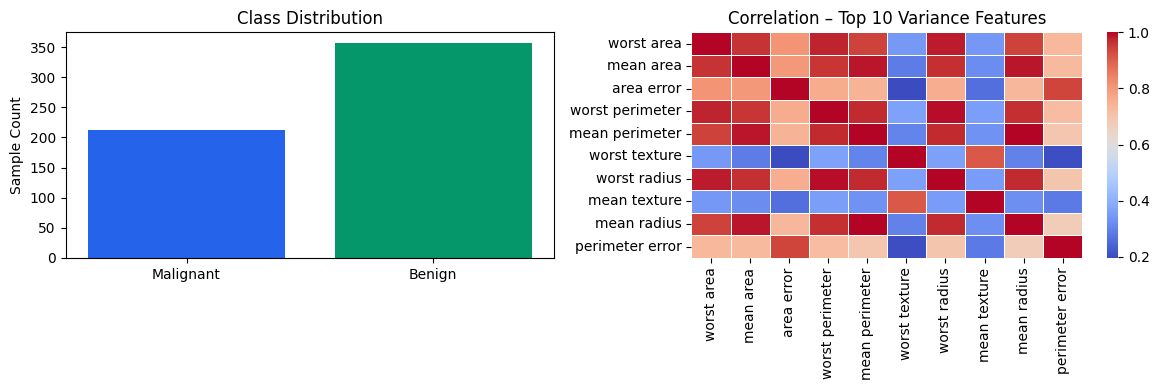

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class distribution
axes[0].bar(['Malignant', 'Benign'],
            [(diagnosis_vec==0).sum(), (diagnosis_vec==1).sum()],
            color=['#2563EB', '#059669'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Sample Count')

# correlation heatmap (top-10 by variance)
top10_feats = feature_matrix.var().nlargest(10).index
axes[1].set_title('Correlation – Top 10 Variance Features')
sns.heatmap(feature_matrix[top10_feats].corr(), ax=axes[1],
            cmap='coolwarm', annot=False, linewidths=0.4)
plt.tight_layout(); plt.show()

In [4]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    feature_matrix, diagnosis_vec,
    test_size=0.20, random_state=42, stratify=diagnosis_vec
)

skf_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [5]:
dt_criterion_opts = ['gini', 'entropy']
dt_maxdepth_opts  = [3, 5, 7, None]
dt_minsplit_opts  = [2, 5, 10]
dt_minleaf_opts   = [1, 2, 4]

best_dt_cv_acc = 0.0
best_dt_config = {}
dt_sweep_log   = []

for crit in dt_criterion_opts:
    for depth in dt_maxdepth_opts:
        for minsplit in dt_minsplit_opts:
            for minleaf in dt_minleaf_opts:
                probe_tree = DecisionTreeClassifier(
                    criterion=crit, max_depth=depth,
                    min_samples_split=minsplit, min_samples_leaf=minleaf,
                    random_state=42
                )
                fold_acc_scores = cross_val_score(
                    probe_tree, X_train_raw, y_train_raw,
                    cv=skf_splitter, scoring='accuracy'
                )
                fold_f1_scores = cross_val_score(
                    probe_tree, X_train_raw, y_train_raw,
                    cv=skf_splitter, scoring='f1'
                )
                avg_acc = fold_acc_scores.mean()
                avg_f1  = fold_f1_scores.mean()
                dt_sweep_log.append({
                    'criterion': crit, 'max_depth': depth,
                    'min_split': minsplit, 'min_leaf': minleaf,
                    'avg_cv_acc': round(avg_acc * 100, 2),
                    'avg_cv_f1':  round(avg_f1, 4)
                })
                if avg_acc > best_dt_cv_acc:
                    best_dt_cv_acc = avg_acc
                    best_dt_config = {
                        'criterion': crit, 'max_depth': depth,
                        'min_samples_split': minsplit, 'min_samples_leaf': minleaf
                    }

print("\nTable 1 – Decision Tree Hyperparameter Evaluation (Top 10):")
dt_sweep_df = (pd.DataFrame(dt_sweep_log)
               .sort_values('avg_cv_acc', ascending=False)
               .head(10)
               .reset_index(drop=True))
print(dt_sweep_df.to_string(index=False))
print(f"\nBest DT config : {best_dt_config}")
print(f"Best DT CV Acc : {round(best_dt_cv_acc*100,2)}%")

rf_nestimators_opts = [50, 100, 200]
rf_maxdepth_opts    = [5, 10, None]
rf_maxfeatures_opts = ['sqrt', 'log2', None]
rf_bootstrap_opts   = [True, False]

best_rf_cv_acc = 0.0
best_rf_config = {}
rf_sweep_log   = []

for n_est in rf_nestimators_opts:
    for depth in rf_maxdepth_opts:
        for mfeat in rf_maxfeatures_opts:
            for bs in rf_bootstrap_opts:
                probe_forest = RandomForestClassifier(
                    n_estimators=n_est, max_depth=depth,
                    max_features=mfeat, bootstrap=bs,
                    random_state=42, n_jobs=-1
                )
                fold_acc_scores = cross_val_score(
                    probe_forest, X_train_raw, y_train_raw,
                    cv=skf_splitter, scoring='accuracy'
                )
                fold_f1_scores = cross_val_score(
                    probe_forest, X_train_raw, y_train_raw,
                    cv=skf_splitter, scoring='f1'
                )
                avg_acc = fold_acc_scores.mean()
                avg_f1  = fold_f1_scores.mean()
                rf_sweep_log.append({
                    'n_estimators': n_est, 'max_depth': depth,
                    'max_features': mfeat, 'bootstrap': bs,
                    'avg_cv_acc': round(avg_acc * 100, 2),
                    'avg_cv_f1':  round(avg_f1, 4)
                })
                if avg_acc > best_rf_cv_acc:
                    best_rf_cv_acc = avg_acc
                    best_rf_config = {
                        'n_estimators': n_est, 'max_depth': depth,
                        'max_features': mfeat, 'bootstrap': bs
                    }

print("\nTable 2 – Random Forest Hyperparameter Evaluation (Top 10):")
rf_sweep_df = (pd.DataFrame(rf_sweep_log)
               .sort_values('avg_cv_acc', ascending=False)
               .head(10)
               .reset_index(drop=True))
print(rf_sweep_df.to_string(index=False))
print(f"\nBest RF config : {best_rf_config}")
print(f"Best RF CV Acc : {round(best_rf_cv_acc*100,2)}%")



Table 1 – Decision Tree Hyperparameter Evaluation (Top 10):
criterion  max_depth  min_split  min_leaf  avg_cv_acc  avg_cv_f1
     gini        7.0         10         4       93.85     0.9506
     gini        5.0         10         4       93.85     0.9506
     gini        5.0          5         4       93.85     0.9506
     gini        NaN         10         4       93.85     0.9506
     gini        5.0          2         4       93.85     0.9506
     gini        7.0          2         4       93.41     0.9470
     gini        NaN          5         4       93.41     0.9470
     gini        7.0          5         4       93.41     0.9470
     gini        NaN          2         4       93.41     0.9470
  entropy        3.0          5         1       93.41     0.9480

Best DT config : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 4}
Best DT CV Acc : 93.85%

Table 2 – Random Forest Hyperparameter Evaluation (Top 10):
 n_estimators  max_depth max_feature

In [6]:
champion_tree = DecisionTreeClassifier(**best_dt_config, random_state=42)
champion_tree.fit(X_train_raw, y_train_raw)

champion_forest = RandomForestClassifier(**best_rf_config, random_state=42, n_jobs=-1)
champion_forest.fit(X_train_raw, y_train_raw)

dt_fold_accs = cross_val_score(
    champion_tree, X_train_raw, y_train_raw,
    cv=skf_splitter, scoring='accuracy'
)
rf_fold_accs = cross_val_score(
    champion_forest, X_train_raw, y_train_raw,
    cv=skf_splitter, scoring='accuracy'
)

print("\nTable 3 – 5-Fold CV Accuracy Comparison:")
fold_compare_df = pd.DataFrame({
    'Model':        ['Decision Tree', 'Random Forest'],
    'Fold 1 (%)':   [round(dt_fold_accs[0]*100,2), round(rf_fold_accs[0]*100,2)],
    'Fold 2 (%)':   [round(dt_fold_accs[1]*100,2), round(rf_fold_accs[1]*100,2)],
    'Fold 3 (%)':   [round(dt_fold_accs[2]*100,2), round(rf_fold_accs[2]*100,2)],
    'Fold 4 (%)':   [round(dt_fold_accs[3]*100,2), round(rf_fold_accs[3]*100,2)],
    'Fold 5 (%)':   [round(dt_fold_accs[4]*100,2), round(rf_fold_accs[4]*100,2)],
    'Average (%)':  [round(dt_fold_accs.mean()*100,2), round(rf_fold_accs.mean()*100,2)],
})
print(fold_compare_df.to_string(index=False))


Table 3 – 5-Fold CV Accuracy Comparison:
        Model  Fold 1 (%)  Fold 2 (%)  Fold 3 (%)  Fold 4 (%)  Fold 5 (%)  Average (%)
Decision Tree       94.51       94.51       91.21       92.31        96.7        93.85
Random Forest       96.70       97.80       93.41       95.60        98.9        96.48



 Decision Tree — Test-Set Evaluation
  Accuracy  : 90.35%
  Precision : 94.2%
  Recall    : 90.28%
  F1-Score  : 92.2%
  AUC-ROC   : 0.9358

  Confusion Matrix:
[[38  4]
 [ 7 65]]

 Random Forest — Test-Set Evaluation
  Accuracy  : 95.61%
  Precision : 95.89%
  Recall    : 97.22%
  F1-Score  : 96.55%
  AUC-ROC   : 0.9924

  Confusion Matrix:
[[39  3]
 [ 2 70]]


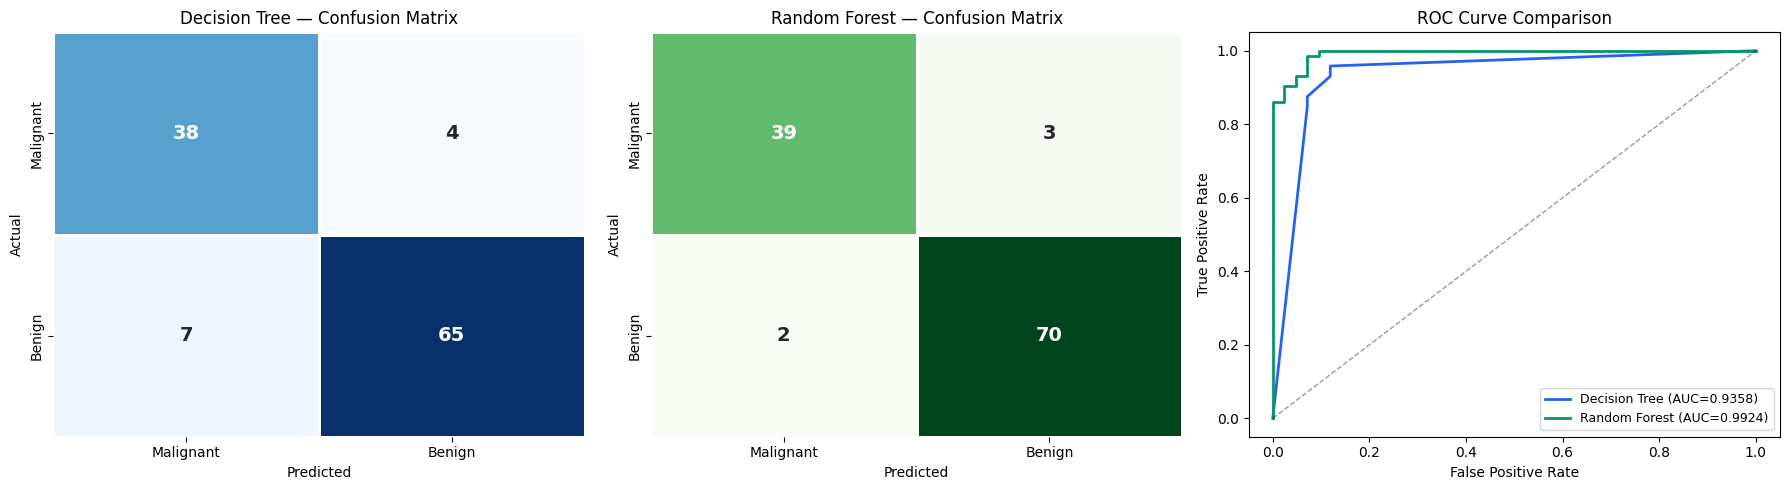

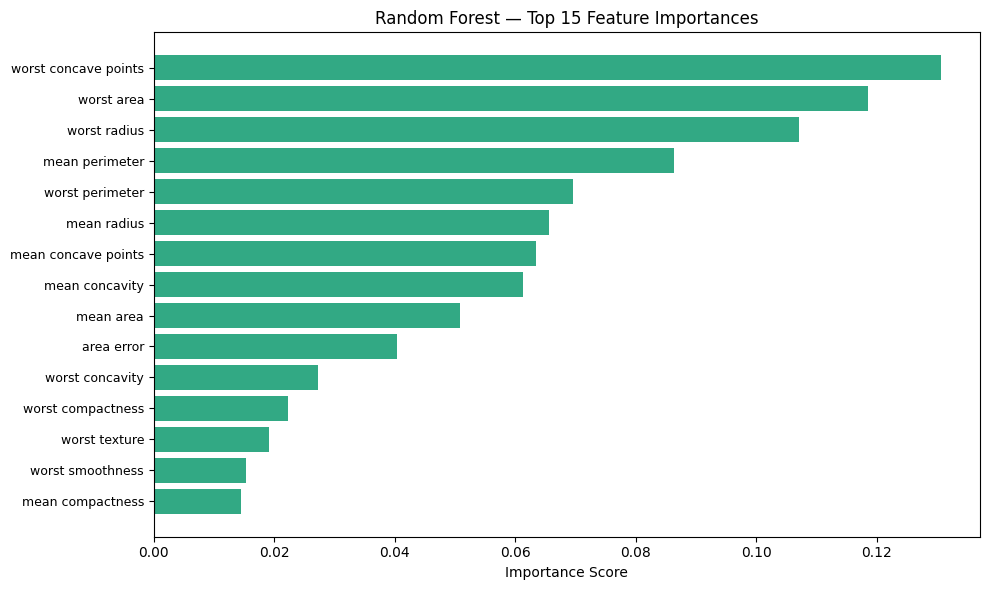

In [7]:
dt_test_preds  = champion_tree.predict(X_test_raw)
rf_test_preds  = champion_forest.predict(X_test_raw)
dt_test_proba  = champion_tree.predict_proba(X_test_raw)[:, 1]
rf_test_proba  = champion_forest.predict_proba(X_test_raw)[:, 1]

def report_metrics(y_true, y_pred, y_proba, model_tag):
    print(f"\n{'='*50}")
    print(f" {model_tag} — Test-Set Evaluation")
    print(f"{'='*50}")
    print(f"  Accuracy  : {round(accuracy_score(y_true,y_pred)*100,2)}%")
    print(f"  Precision : {round(precision_score(y_true,y_pred)*100,2)}%")
    print(f"  Recall    : {round(recall_score(y_true,y_pred)*100,2)}%")
    print(f"  F1-Score  : {round(f1_score(y_true,y_pred)*100,2)}%")
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    print(f"  AUC-ROC   : {round(auc(fpr,tpr),4)}")
    print(f"\n  Confusion Matrix:\n{confusion_matrix(y_true,y_pred)}")

report_metrics(y_test_raw, dt_test_preds, dt_test_proba, 'Decision Tree')
report_metrics(y_test_raw, rf_test_preds, rf_test_proba, 'Random Forest')

# ─── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax, cm, title, cmap in zip(
        axes[:2],
        [confusion_matrix(y_test_raw, dt_test_preds),
         confusion_matrix(y_test_raw, rf_test_preds)],
        ['Decision Tree', 'Random Forest'],
        ['Blues', 'Greens']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Malignant','Benign'],
                yticklabels=['Malignant','Benign'],
                linewidths=0.8, linecolor='white',
                annot_kws={'size':14,'weight':'bold'}, cbar=False)
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ROC curves
dt_fpr, dt_tpr, _ = roc_curve(y_test_raw, dt_test_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test_raw, rf_test_proba)
axes[2].plot(dt_fpr, dt_tpr, color='#2563EB', lw=2,
             label=f"Decision Tree (AUC={round(auc(dt_fpr,dt_tpr),4)})")
axes[2].plot(rf_fpr, rf_tpr, color='#059669', lw=2,
             label=f"Random Forest (AUC={round(auc(rf_fpr,rf_tpr),4)})")
axes[2].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

# Feature importances
feat_pairs  = sorted(zip(wdbc_bundle.feature_names,
                          champion_forest.feature_importances_),
                     key=lambda x: x[1], reverse=True)[:15]
feat_names, feat_vals = zip(*feat_pairs)
plt.figure(figsize=(10, 6))
plt.barh(range(15), feat_vals, color='#059669', alpha=0.82)
plt.yticks(range(15), feat_names, fontsize=9)
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout(); plt.show()